# Data Preparation
## 12-Month Hospitalization Risk in Senior Living Populations

This notebook loads CMS SynPUF Sample 1 data, engineers features from beneficiary demographics, chronic conditions, and baseline utilization, and creates the target variable for hospitalization prediction.

## Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [2]:
beneficiary_file = '../data/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv'
inpatient_file = '../data/DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv'
outpatient_file = '../data/DE1_0_2008_to_2010_Outpatient_Claims_Sample_1.csv'
carrier_file = '../data/DE1_0_2008_to_2010_Carrier_Claims_Sample_1A.csv'

print("Loading CMS SynPUF data files...")
beneficiary_df = pd.read_csv(beneficiary_file)
print(f"Loaded beneficiaries: {len(beneficiary_df)}")

inpatient_df = pd.read_csv(inpatient_file)
print(f"Loaded inpatient claims: {len(inpatient_df)}")

outpatient_df = pd.read_csv(outpatient_file)
print(f"Loaded outpatient claims: {len(outpatient_df)}")

try:
    carrier_df = pd.read_csv(carrier_file)
    has_carrier = True
    print(f"Loaded carrier claims: {len(carrier_df)}")
except:
    print("Carrier file not found - continuing without it")
    has_carrier = False

Loading CMS SynPUF data files...
Loaded beneficiaries: 116352
Loaded inpatient claims: 66773
Loaded outpatient claims: 790790
Loaded carrier claims: 2370667


## Temporal Structure

```
[2008: Feature Calculation Period] → [Prediction Point: Jan 1, 2009] → [2009: Outcome Period]
```

In [3]:
inpatient_df['CLM_FROM_DT'] = pd.to_datetime(inpatient_df['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')
inpatient_df['year'] = inpatient_df['CLM_FROM_DT'].dt.year

baseline_year = 2008
prediction_year = 2009

print(f"Baseline period: {baseline_year}")
print(f"Prediction period: {prediction_year}")

Baseline period: 2008
Prediction period: 2009


## Demographics and Chronic Conditions

In [4]:
df = beneficiary_df.copy()

df['age'] = 2008 - df['BENE_BIRTH_DT'].astype(str).str[:4].astype(int)
df['gender'] = df['BENE_SEX_IDENT_CD'].map({1: 'Male', 2: 'Female'})
print("Created age and gender features")

chronic_condition_mapping = {
    'SP_ALZHDMTA': 'has_alzheimers',
    'SP_CHF': 'has_chf',
    'SP_CHRNKIDNEY': 'has_ckd',
    'SP_CNCR': 'has_cancer',
    'SP_COPD': 'has_copd',
    'SP_DEPRESSN': 'has_depression',
    'SP_DIABETES': 'has_diabetes',
    'SP_ISCHMCHT': 'has_ihd',
    'SP_OSTEOPRS': 'has_osteoporosis',
    'SP_RA_OA': 'has_arthritis',
    'SP_STRKETIA': 'has_stroke'
}

available_condition_cols = [col for col in chronic_condition_mapping.keys() if col in df.columns]

for orig_col, new_col in chronic_condition_mapping.items():
    if orig_col in df.columns:
        df[new_col] = (df[orig_col] == 1).astype(int)
    else:
        df[new_col] = 0

df['num_chronic_conditions'] = df[[chronic_condition_mapping[col] for col in available_condition_cols]].sum(axis=1)
print(f"Calculated chronic conditions (found {len(available_condition_cols)} columns)")

Created age and gender features
Calculated chronic conditions (found 10 columns)


## Baseline Utilization Features (2008)

In [5]:
# Inpatient utilization
baseline_inpatient = inpatient_df[inpatient_df['year'] == baseline_year]
baseline_utilization = baseline_inpatient.groupby('DESYNPUF_ID').agg({
    'CLM_ID': 'count',
    'CLM_PMT_AMT': 'sum',
    'CLM_UTLZTN_DAY_CNT': 'sum'
}).rename(columns={
    'CLM_ID': 'baseline_hospital_admits',
    'CLM_PMT_AMT': 'baseline_inpatient_cost',
    'CLM_UTLZTN_DAY_CNT': 'baseline_hospital_days'
})

df = df.merge(baseline_utilization, on='DESYNPUF_ID', how='left')
df[['baseline_hospital_admits', 'baseline_inpatient_cost', 'baseline_hospital_days']] = \
    df[['baseline_hospital_admits', 'baseline_inpatient_cost', 'baseline_hospital_days']].fillna(0)
print("Merged baseline inpatient utilization")

Merged baseline inpatient utilization


In [6]:
# Outpatient utilization
outpatient_df['CLM_FROM_DT'] = pd.to_datetime(outpatient_df['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')
outpatient_df['year'] = outpatient_df['CLM_FROM_DT'].dt.year

baseline_outpatient = outpatient_df[outpatient_df['year'] == baseline_year]
print(f"Filtered baseline outpatient claims: {len(baseline_outpatient)}")

baseline_outpatient_util = baseline_outpatient.groupby('DESYNPUF_ID').agg({
    'CLM_ID': 'count',
    'CLM_PMT_AMT': 'sum'
}).rename(columns={
    'CLM_ID': 'baseline_outpatient_visits',
    'CLM_PMT_AMT': 'baseline_outpatient_cost'
})

df = df.merge(baseline_outpatient_util, on='DESYNPUF_ID', how='left')
df[['baseline_outpatient_visits', 'baseline_outpatient_cost']] = \
    df[['baseline_outpatient_visits', 'baseline_outpatient_cost']].fillna(0)
print("Merged baseline outpatient utilization")

# Estimated ER visits (proxy)
df['baseline_er_visits'] = df['baseline_outpatient_visits'] * 0.15
print("Estimated baseline ER visits")

Filtered baseline outpatient claims: 282896
Merged baseline outpatient utilization
Estimated baseline ER visits


In [7]:
# Physician/carrier visits
if has_carrier:
    print("Processing carrier/physician visits...")
    carrier_df['CLM_FROM_DT'] = pd.to_datetime(carrier_df['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')
    carrier_df['year'] = carrier_df['CLM_FROM_DT'].dt.year
    
    baseline_carrier = carrier_df[carrier_df['year'] == baseline_year]
    print(f"Filtered baseline carrier claims: {len(baseline_carrier)}")
    
    baseline_carrier_util = baseline_carrier.groupby('DESYNPUF_ID').agg({
        'CLM_ID': 'count'
    }).rename(columns={
        'CLM_ID': 'baseline_physician_visits'
    })
    
    df = df.merge(baseline_carrier_util, on='DESYNPUF_ID', how='left')
    df['baseline_physician_visits'] = df['baseline_physician_visits'].fillna(0)
    print("Merged baseline physician visits")
else:
    df['baseline_physician_visits'] = 0
    print("Set baseline physician visits to 0 (no carrier data)")

Processing carrier/physician visits...
Filtered baseline carrier claims: 857411
Merged baseline physician visits


## Target Variable (2009 Hospitalizations)

In [8]:
future_inpatient = inpatient_df[inpatient_df['year'] == prediction_year]
print(f"Filtered future inpatient claims: {len(future_inpatient)}")

future_utilization = future_inpatient.groupby('DESYNPUF_ID').agg({
    'CLM_ID': 'count',
    'CLM_PMT_AMT': 'sum'
}).rename(columns={
    'CLM_ID': 'future_hospital_admits',
    'CLM_PMT_AMT': 'future_inpatient_cost'
})

df = df.merge(future_utilization, on='DESYNPUF_ID', how='left')
df[['future_hospital_admits', 'future_inpatient_cost']] = \
    df[['future_hospital_admits', 'future_inpatient_cost']].fillna(0)

df['hospitalization_risk'] = (df['future_hospital_admits'] >= 1).astype(int)
print("Created target variable (hospitalization_risk)")

Filtered future inpatient claims: 25231
Created target variable (hospitalization_risk)


## Engineered Features

In [9]:
# Clinical composites
df['high_risk_conditions'] = (
    df['has_chf'] + df['has_copd'] + df['has_ckd'] + 
    df['has_diabetes'] + df['has_alzheimers']
)
df['cardiovascular_burden'] = df['has_chf'] + df['has_ihd'] + df['has_stroke']
df['respiratory_disease'] = df['has_copd'].astype(int)
df['renal_disease'] = df['has_ckd'].astype(int)
df['cognitive_impairment'] = df['has_alzheimers'].astype(int)

# Utilization flags
df['polypharmacy_proxy'] = (df['num_chronic_conditions'] >= 5).astype(int)
df['prior_utilizer'] = (df['baseline_hospital_admits'] >= 1).astype(int)
df['frequent_prior_user'] = (df['baseline_hospital_admits'] >= 2).astype(int)
df['high_er_user'] = (df['baseline_er_visits'] >= 2).astype(int)
df['high_outpatient_user'] = (df['baseline_outpatient_visits'] >= df['baseline_outpatient_visits'].quantile(0.75)).astype(int)

# Composite scores
df['age_risk_score'] = df['age'] * df['num_chronic_conditions']
df['er_utilization_score'] = df['baseline_er_visits'] * 3 + df['baseline_hospital_admits'] * 2
df['total_baseline_visits'] = df['baseline_hospital_admits'] + df['baseline_outpatient_visits'] + df['baseline_physician_visits']

# Cost features
df['baseline_cost_per_day'] = np.where(
    df['baseline_hospital_days'] > 0,
    df['baseline_inpatient_cost'] / df['baseline_hospital_days'],
    0
)
df['baseline_total_cost'] = df['baseline_inpatient_cost'] + df['baseline_outpatient_cost']

print("Engineered features created")

Engineered features created


## Final Dataset Assembly

In [10]:
feature_cols = [
    'age', 'gender', 'num_chronic_conditions',
    'has_alzheimers', 'has_chf', 'has_ckd', 'has_copd', 'has_diabetes', 'has_depression',
    'has_cancer', 'has_ihd', 'has_osteoporosis', 'has_arthritis', 'has_stroke',
    'baseline_hospital_admits', 'baseline_hospital_days', 'baseline_inpatient_cost',
    'baseline_outpatient_visits', 'baseline_outpatient_cost', 'baseline_physician_visits',
    'baseline_er_visits', 'baseline_total_cost',
    'high_risk_conditions', 'cardiovascular_burden', 'respiratory_disease', 
    'renal_disease', 'cognitive_impairment',
    'polypharmacy_proxy', 'prior_utilizer', 'frequent_prior_user', 
    'high_er_user', 'high_outpatient_user',
    'age_risk_score', 'er_utilization_score', 'total_baseline_visits',
    'baseline_cost_per_day',
    'hospitalization_risk'
]

df_model = df[['DESYNPUF_ID'] + feature_cols].copy()
df_model = df_model.dropna(subset=['age', 'gender', 'hospitalization_risk'])

df_model.to_csv('../data/hospitalization_risk_data.csv', index=False)

print(f"Dataset shape: {df_model.shape}")
print(f"\nTarget variable distribution:")
print(f"No hospitalization in {prediction_year}: {(df_model['hospitalization_risk'] == 0).sum()} ({(df_model['hospitalization_risk'] == 0).sum() / len(df_model) * 100:.1f}%)")
print(f"Had hospitalization in {prediction_year}: {(df_model['hospitalization_risk'] == 1).sum()} ({(df_model['hospitalization_risk'] == 1).sum() / len(df_model) * 100:.1f}%)")

print(f"\nBaseline utilization statistics:")
print(f"Patients with baseline hospitalizations: {(df_model['baseline_hospital_admits'] > 0).sum()} ({(df_model['baseline_hospital_admits'] > 0).sum() / len(df_model) * 100:.1f}%)")
print(f"Mean baseline admits: {df_model['baseline_hospital_admits'].mean():.2f}")
print(f"Mean baseline ER visits: {df_model['baseline_er_visits'].mean():.2f}")
print(f"Mean baseline outpatient visits: {df_model['baseline_outpatient_visits'].mean():.2f}")
print(f"Mean baseline physician visits: {df_model['baseline_physician_visits'].mean():.2f}")
print(f"Mean chronic conditions: {df_model['num_chronic_conditions'].mean():.2f}")

print(f"\nData saved to: ../data/hospitalization_risk_data.csv")

Dataset shape: (116352, 38)

Target variable distribution:
No hospitalization in 2009: 97521 (83.8%)
Had hospitalization in 2009: 18831 (16.2%)

Baseline utilization statistics:
Patients with baseline hospitalizations: 15861 (13.6%)
Mean baseline admits: 0.24
Mean baseline ER visits: 0.36
Mean baseline outpatient visits: 2.43
Mean baseline physician visits: 7.37
Mean chronic conditions: 2.06

Data saved to: ../data/hospitalization_risk_data.csv


## Exploratory Data Analysis

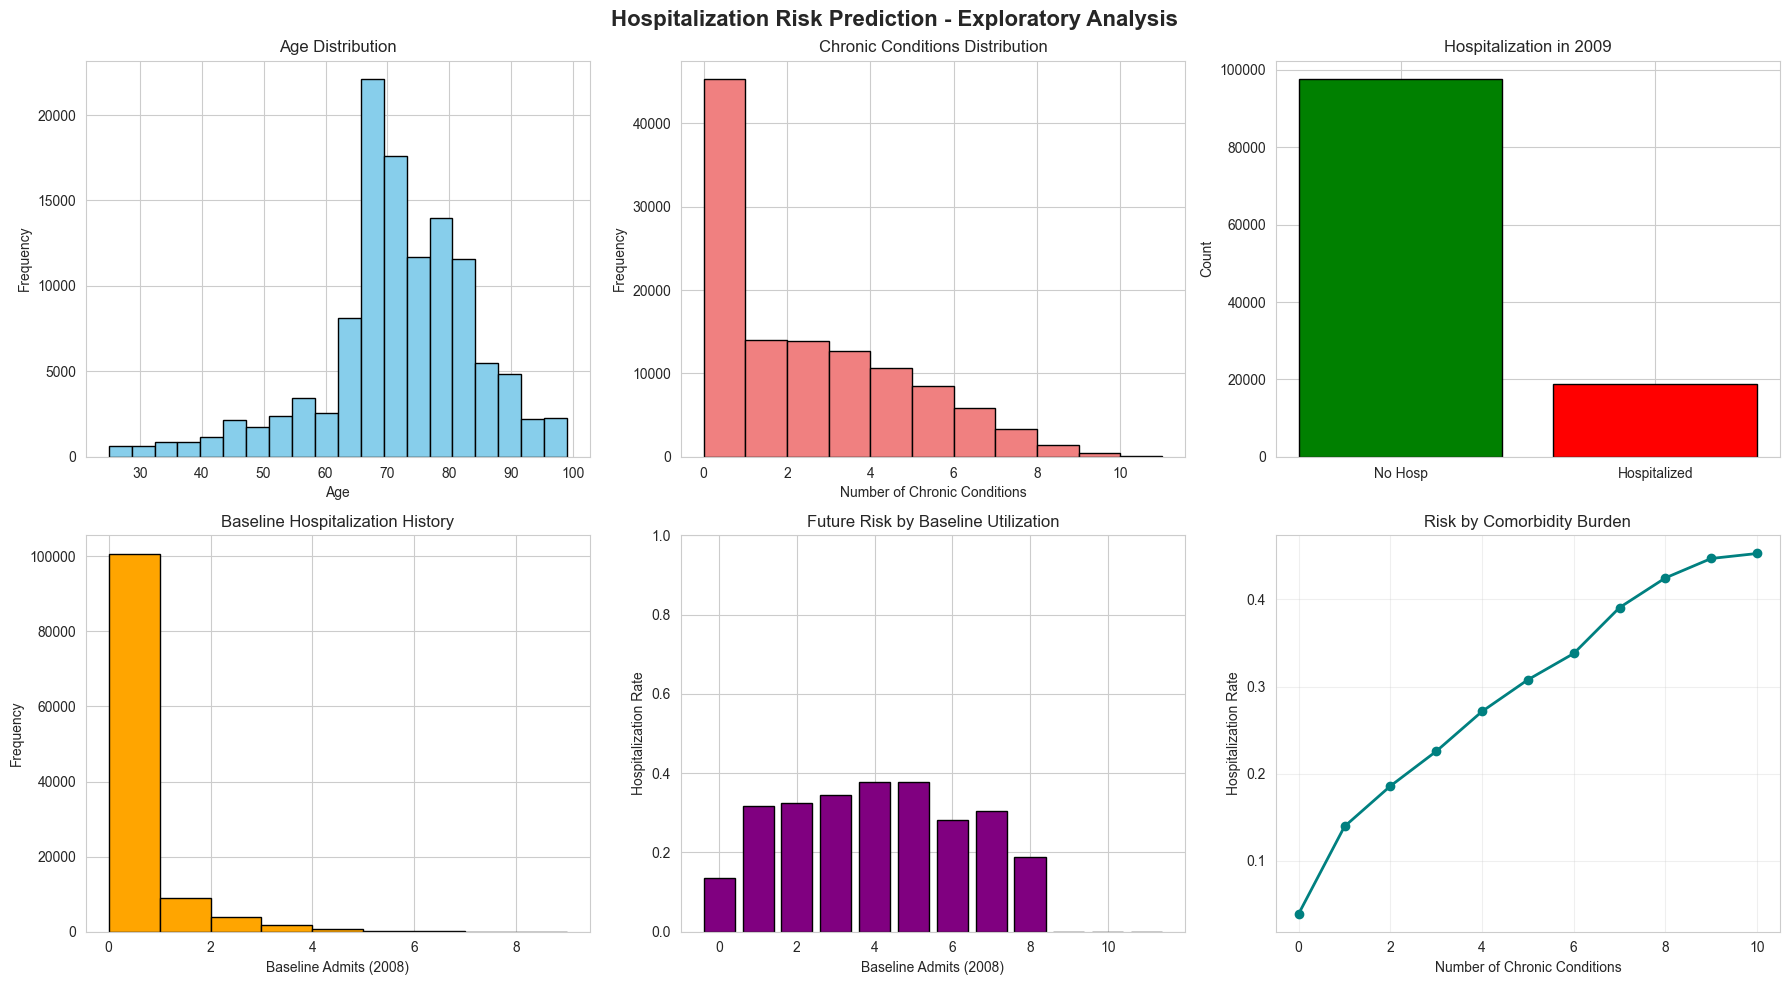

In [11]:
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hospitalization Risk Prediction - Exploratory Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(df_model['age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution')

axes[0, 1].hist(df_model['num_chronic_conditions'], bins=range(0, 12), color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Chronic Conditions')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Chronic Conditions Distribution')

risk_colors = ['green', 'red']
risk_counts = df_model['hospitalization_risk'].value_counts().sort_index()
axes[0, 2].bar(['No Hosp', 'Hospitalized'], risk_counts.values, color=risk_colors, edgecolor='black')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title(f'Hospitalization in {prediction_year}')

axes[1, 0].hist(df_model['baseline_hospital_admits'], bins=range(0, 10), color='orange', edgecolor='black')
axes[1, 0].set_xlabel(f'Baseline Admits ({baseline_year})')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Baseline Hospitalization History')

risk_by_baseline = df_model.groupby('baseline_hospital_admits')['hospitalization_risk'].mean()
axes[1, 1].bar(risk_by_baseline.index, risk_by_baseline.values, color='purple', edgecolor='black')
axes[1, 1].set_xlabel(f'Baseline Admits ({baseline_year})')
axes[1, 1].set_ylabel('Hospitalization Rate')
axes[1, 1].set_title(f'Future Risk by Baseline Utilization')
axes[1, 1].set_ylim([0, 1])

risk_by_conditions = df_model.groupby('num_chronic_conditions')['hospitalization_risk'].mean()
axes[1, 2].plot(risk_by_conditions.index, risk_by_conditions.values, marker='o', color='teal', linewidth=2)
axes[1, 2].set_xlabel('Number of Chronic Conditions')
axes[1, 2].set_ylabel('Hospitalization Rate')
axes[1, 2].set_title('Risk by Comorbidity Burden')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/eda_hospitalization_risk.png', dpi=300, bbox_inches='tight')
plt.show()

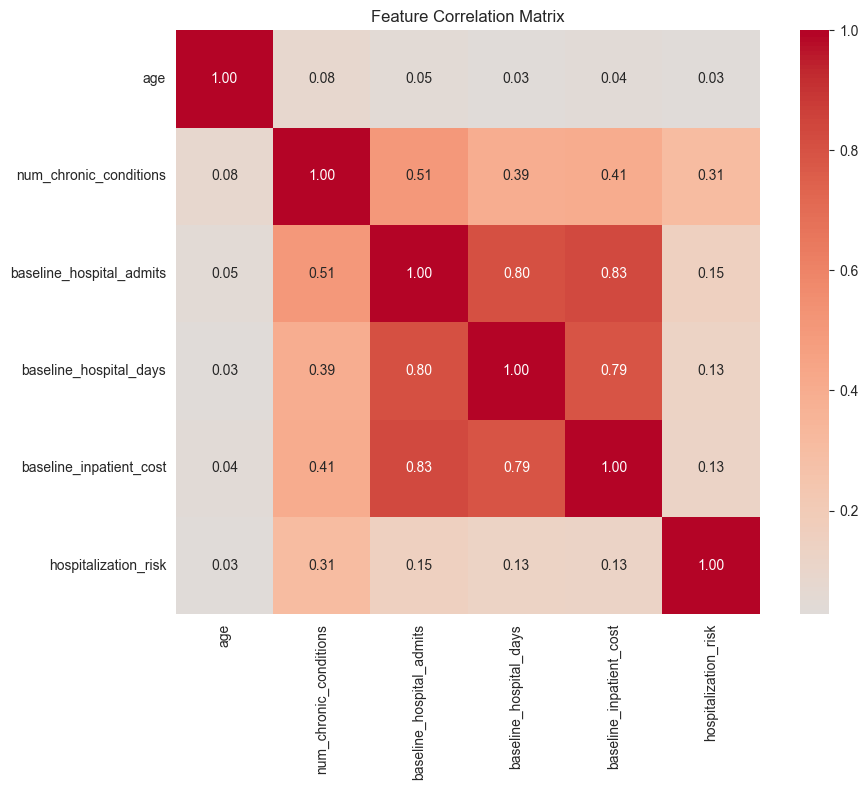

Data preparation complete


In [12]:
numeric_cols = ['age', 'num_chronic_conditions', 'baseline_hospital_admits', 
                'baseline_hospital_days', 'baseline_inpatient_cost', 'hospitalization_risk']
corr_matrix = df_model[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Data preparation complete")